## Getting Started

This notebook shows how to set up `SIMBA`, load in a `LAURA` object and settings for tracking, and plot the results, using the openly available [JFEL](https://github.com/astec-stfc/laura-lattices/tree/main/JFEL) lattice from the [laura-lattices](https://github.com/astec-stfc/laura-lattices) repository.

It is assumed that `laura-lattices` has been cloned, and that a `SimCodes` directory has been prepared (see the docs [here](https://simba-accelerator.readthedocs.io/en/latest/SimCodes.html)), with both locations set via the `LATTICE_LOCATION` and `SIMCODES` environment variables, e.g.

```bash
git clone https://github.com/astec-stfc/laura-lattices.git
export LATTICE_LOCATION=$(pwd)/laura-lattices/JFEL
export SIMCODES=/path/to/simcodes/directory
```

For a simpler introduction that needs neither of these (a FODO built from scratch, tracked in pure python), see the [Getting Started](https://simba-accelerator.readthedocs.io/en/latest/getting-started.html) docs page instead.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import simba.Framework as fw  # noqa E402
from simba.Framework import load_directory  # noqa E402
import simba.Modules.Beams as rbf  # noqa E402
import simba.Modules.Twiss as rtf  # noqa E402

# Define a new framework instance, in directory 'getting_started'.
#       "clean" will empty (delete everything!) in the directory if true
#       "verbose" will print a progressbar if true
framework = fw.Framework(
        simcodes=os.environ["SIMCODES"],
        directory="./getting_started",
        master_lattice=os.environ["LATTICE_LOCATION"],
        generator_defaults="jfel.yaml",
        clean=False,
        verbose=False
    )

scaling = 2

initializing ocelot...


### Preparing the simulation and tracking

Load a lattice definition file from ``LATTICE_LOCATION``.

In [2]:
framework.loadSettings("Lattices/jfel_combined.def")
startline = "generator"
endline = "Linac"

Enable collective effects for the Linac section (LSC everywhere, CSR through the bunch compressor).

In [3]:
framework["Linac"].lsc_enable = True
framework["Linac"].csr_enable = True

This is the code that generates the laser distribution (ASTRA or GPT)

In [4]:
framework.change_generator("ASTRA")

Load a starting laser distribution setting

In [5]:
framework.generator.load_defaults("jfel_400_3ps")

Set the thermal emittance for the generator

In [6]:
framework.generator.thermal_emittance = 0.0005

This is a scaling parameter. it defines the number of particles to create at the gun (this is "ASTRA generator" which creates distributions).
The space charge 3D mesh in ASTRA/GPT performs best if the number of particles is a power of 8.

In [7]:
framework.generator.number_of_particles = 2 ** (3 * scaling)

Modify some lattice parameters

In [8]:
framework["JFEL-S02-MAG-QUAD-01"].k1l += 0.1
framework["JFEL-L03-LIN-CAV-01"].phase += 5
framework["bunch_compressor"].set_angle(0.090)

Generate and track the bunch

In [9]:
framework.track(startfile=startline, endfile=endline)

/home/xkc85723/Documents/laura/laura/models/baseModels.py:326: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Unexpected Value)
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='field_amplitude', input_value=0, input_type=int])
  return handler(self)  # default dict for python
/home/xkc85723/Documents/laura/laura/models/baseModels.py:326: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Unexpected Value)
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='field_amplitude', input_value=0, input_type=int])
  PydanticSerializationUnexpectedValue(Unexpected Value)
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='field_amplitude', input_value=0, input_type=int])
  return handler(self)  # default dict for python
/home/xkc85723/venv/lib/python3.12/site-

The outputs from the simulation can now be loaded as follows, and we can plot the beam evolution along the line

In [10]:
fwdir = load_directory("./getting_started", beams=True)

/home/xkc85723/Documents/simba/simba/Framework.py:299: UserWarning: Either `simcodes` location or `container_runtime` must be either 'docker' or 'apptainer' to set up executables;Cannot run simulations without either of these - please set one or the other
  warn("Either `simcodes` location or `container_runtime` must be either 'docker' or 'apptainer' to set up executables;"


Found MasterLattice Package = /tmp/claude-1001/-home-xkc85723-Documents-simba/84342cd9-c048-415a-9401-b8b77748d5ed/scratchpad/lattice-work/laura-lattices/JFEL/./
Found SimCodes Package = /home/xkc85723/Documents/simcodes/SimCodes/./


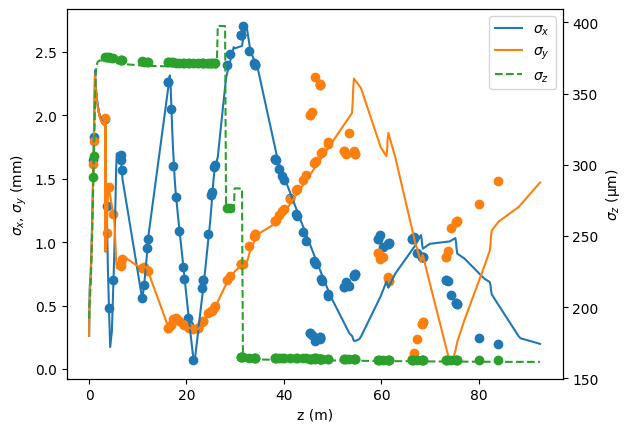

In [11]:
plt1, fig1, ax1 = fwdir.plot(include_layout=False, include_particles=True, ykeys=['sigma_x', 'sigma_y'], ykeys2=['sigma_z'])

In [12]:
import shutil
shutil.rmtree('./getting_started/')